In [1]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras

import string
import re

In [ ]:
# loading the dataset
df = pd.read_csv('english_to_german.csv')
df.head()

,English,German
0,Hi,Hallo!
1,Hi,Grüß Gott!
2,Run!,Lauf!
3,Run,Lauf!
4,Wow!,Potzdonner!


In [ ]:
# cleaning the dataset
df.columns = df.columns.str.strip()
df['source'] = df['English']
df['target'] = df['German'].apply(lambda x: '[start] ' + x + ' [end]')
df = df.drop(['English', 'German'], axis=1)
display(df.sample(5))

,source,target
23774,Tom didn't follow,[start] Tom folgte nicht nach [end]
63804,I like listening to him,[start] Ich höre ihm gern zu [end]
72342,I overslept this morning,[start] Ich habe heute Morgen verschlafen [end]
176300,Tom has been offered a job in Australia,[start] Tom hat ein Arbeitsplatzangebot aus Au...
35645,No one could see us,[start] Niemand konnte uns sehen [end]


In [ ]:
# shuffling the dataset
df = df.sample(frac=1).reset_index(drop=True)

# splitting into train, validation, and test sets
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.2)
test_size = int(len(df) * 0.1)

train_df = df[:train_size]
val_df = df[train_size:train_size+val_size]
test_df = df[train_size+val_size:]

In [ ]:
# hyperparameters
max_tokens = 25000
sequence_length = 30

# removing punctuations except "[" and "]"
strip_chars = string.punctuation
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")

def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(
        lowercase, f"[{re.escape(strip_chars)}]", "")

# source tokenizer
source_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length,
)
# target tokenizer
target_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length + 1, # +1 for the shift
    standardize=custom_standardization,
)

# adapting the tokenizers to the training data
train_source_texts = train_df['source'].values
train_target_texts = train_df['target'].values
source_vectorization.adapt(train_source_texts)
target_vectorization.adapt(train_target_texts)

In [ ]:
# saving the tokenizers
import json

json.dump(source_vectorization.get_vocabulary(), open("source_vocab_re.json","w"))
json.dump(target_vectorization.get_vocabulary(), open("target_vocab_re.json","w"))

In [ ]:
# Positional Embedding Layer

class PositionalEmbedding(keras.layers.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        # Token embedding: turns word indices into vectors
        self.token_embeddings = keras.layers.Embedding(input_dim=input_dim, output_dim=output_dim) # token embedding layer
        # Position embedding: turns position indices into vectors
        self.position_embeddings = keras.layers.Embedding(input_dim=sequence_length, output_dim=output_dim) # position embedding layer
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):
        embedded_tokens = self.token_embeddings(inputs) 
        length = tf.shape(inputs)[-1] # Find length of input sequence
        positions = tf.range(start=0, limit=length, delta=1) # Generate positions (0 to length-1)
        embedded_positions = self.position_embeddings(positions) 
        return embedded_tokens + embedded_positions

    # Mask padding tokens (value 0)
    def compute_mask(self, inputs, mask=None):
        return keras.ops.not_equal(inputs, 0)

    # To save model config later
    def get_config(self):
        config = super(PositionalEmbedding, self).get_config()
        config.update({
            "input_dim": self.input_dim,
            "output_dim": self.output_dim,
            "sequence_length": self.sequence_length,
        })
        return config

In [ ]:
# Helper function to get tensor shape (works with dynamic shapes)
def shape_list(x):
    static = x.shape.as_list()
    dynamic = tf.shape(x)
    return [dynamic[i] if s is None else s for i, s in enumerate(static)]

# Create triangular attention mask (for causal attention)
def attention_mask(nd, ns, *, dtype):
    i = tf.range(nd)[:,None]
    j = tf.range(ns)
    m = i >= j - ns + nd
    return tf.cast(m, dtype)

# Apply attention mask to weight matrix
def mask_attn_weights(w):
    _, _, nd, ns = shape_list(w)
    b = attention_mask(nd, ns, dtype=w.dtype)
    b = tf.reshape(b, [1, 1, nd, ns])
    w = w*b - tf.cast(1e10, w.dtype)*(1-b)
    return w

In [9]:
def scaled_dot_product_attention_with_weights(q, k, v, use_causal_mask=False):
    # q,k,v shape: [batch, heads, seq_len, depth]
    d_k = tf.cast(tf.shape(k)[-1], tf.float32)
    scores = tf.matmul(q, k, transpose_b=True)  # [batch, heads, q_len, k_len]
    scaled_scores = scores / tf.math.sqrt(d_k)
    if use_causal_mask:
        scaled_scores = mask_attn_weights(scaled_scores)
    weights = tf.nn.softmax(scaled_scores, axis=-1)  # attention weights
    output = tf.matmul(weights, v)
    return output, weights

In [ ]:
# Multi Head Attention Layer

class MultiHeadAttention(keras.layers.Layer):
    def __init__(self, embed_dim, h, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.h = h
        if embed_dim % h != 0:
            raise ValueError("embed_dim must be divisible by number of heads")
        # Linear layers to get Q, K, V vectors
        self.q_linear = keras.layers.Dense(embed_dim)
        self.k_linear = keras.layers.Dense(embed_dim)
        self.v_linear = keras.layers.Dense(embed_dim)
        self.concat_linear = keras.layers.Dense(embed_dim)

    # Split the embedding into h heads
    def split_heads(self, x, batch_size):
        x = tf.reshape(x, shape=(batch_size, -1, self.h, self.embed_dim // self.h))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    # Concatenate the heads back into a single embedding
    def concat_heads(self, x, batch_size):
        x = tf.transpose(x, perm=[0, 2, 1, 3])
        return tf.reshape(x, (batch_size, -1, self.embed_dim))

    def call(self, q, k, v, use_causal_mask=False, return_attn_weights=False):
        batch_size = tf.shape(k)[0]
        q = self.q_linear(q)
        k = self.k_linear(k)
        v = self.v_linear(v)
         # Split heads for multi-head attention
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)
        out, weights = scaled_dot_product_attention_with_weights(q, k, v, use_causal_mask)
        concat = self.concat_heads(out, batch_size)
        concat = self.concat_linear(concat)
        if return_attn_weights:
            return concat, weights
        return concat

    def get_config(self):
        config = super(MultiHeadAttention, self).get_config()
        config.update({"embed_dim": self.embed_dim, "h": self.h})
        return config

In [ ]:
# Encoder Layer

class TransformerEncoder(keras.layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads

        # Layer Normalization
        self.layer_norm_1 = keras.layers.LayerNormalization()
        self.layer_norm_2 = keras.layers.LayerNormalization()
        
        # Multi-Head Attention
        self.global_self_attention = MultiHeadAttention(embed_dim=embed_dim, h=num_heads)
        
        # Feed Forward Network
        self.feed_forward = keras.Sequential(
            [keras.layers.Dense(dense_dim, activation="relu"),
             keras.layers.Dense(embed_dim),]
        )

    def call(self, x):
        # Self-attention + residual + normalization
        x = self.layer_norm_1(x + self.global_self_attention(q=x, k=x, v=x))
        # Feed-forward + residual + normalization
        x = self.layer_norm_2(x + self.feed_forward(x))
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "dense_dim": self.dense_dim,
            "num_heads": self.num_heads,
        })
        return config

In [ ]:
# Decoder Layer

class TransformerDecoder(keras.layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads

        # Self-attention but with causal mask (can’t see future tokens)
        self.causal_self_attention = MultiHeadAttention(embed_dim=embed_dim, h=num_heads)
        
        # Cross-attention to encoder output
        self.cross_attention = MultiHeadAttention(embed_dim=embed_dim, h=num_heads)
        
        # Feed Forward Network
        self.feed_forward = keras.Sequential(
            [keras.layers.Dense(dense_dim, activation="relu"),
             keras.layers.Dense(embed_dim),]
        )

        # Layer Normalization
        self.layer_norm_1 = keras.layers.LayerNormalization()
        self.layer_norm_2 = keras.layers.LayerNormalization()
        self.layer_norm_3 = keras.layers.LayerNormalization()

    # context = encoder output
    def call(self, x, context, return_cross_attn=False):
        # Masked self-attention + residual + norm
        x = self.layer_norm_1(x + self.causal_self_attention(q=x, k=x, v=x, use_causal_mask=True))
        
        # get cross-attention outputs and weights
        cross_out = self.cross_attention(q=x, k=context, v=context, return_attn_weights=return_cross_attn)
        if return_cross_attn:
            cross_concat, attn_weights = cross_out
            x = self.layer_norm_2(x + cross_concat)
        else:
            x = self.layer_norm_2(x + cross_out)
            attn_weights = None

        # FFN + residual + norm
        x = self.layer_norm_3(x + self.feed_forward(x))
        if return_cross_attn:
            return x, attn_weights
        return x

In [ ]:
batch_size = 64

def format_dataset(source, target):
    source_vectors = source_vectorization(source)
    target_vectors = target_vectorization(target)
    return ({
        "source": source_vectors, # encoder_inputs
        "target": target_vectors[:, :-1], # decoder_inputs (truncate by 1 to keep it at the same length as decoder_outputs)
    }, target_vectors[:, 1:]) # decoder_outputs

def make_dataset(df):
    dataset = tf.data.Dataset.from_tensor_slices((df["source"].values, df["target"].values))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset, num_parallel_calls=4)
    return dataset.shuffle(2048).prefetch(16).cache()

train_ds = make_dataset(train_df)
val_ds = make_dataset(val_df)

In [ ]:
embed_dim = 512 # dimension of the embedding space
dense_dim = 2048 # dimension of the feed forward network
num_heads = 8

# the transformer body
encoder_inputs = keras.Input(shape=(None,), dtype="int64", name="source")
x = PositionalEmbedding(sequence_length, max_tokens, embed_dim)(encoder_inputs)
encoder_outputs = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)
decoder_inputs = keras.Input(shape=(None,), dtype="int64", name="target")
x = PositionalEmbedding(sequence_length, max_tokens, embed_dim)(decoder_inputs)
x = TransformerDecoder(embed_dim, dense_dim, num_heads)(x, encoder_outputs)

# the transformer head
x = keras.layers.Dropout(0.5)(x)
decoder_outputs = keras.layers.Dense(max_tokens, activation="softmax")(x)

transformer = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'transformer_encoder' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'transformer_decoder' (of type TransformerDecoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [ ]:
# Compile the transformer model
transformer.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy", # since target tokens are integer encoded
    metrics=["accuracy"])

EPOCHS = 50
checkpoint_filepath = '/tmp/checkpoint.weights.h5'

# Callbacks to improve training
callbacks_list = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.1,
        patience=3,
    ),
    # Stop training early if model not improving
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,
        monitor='val_loss',
        mode='min',
        save_best_only=True
    ),
]

# Model training
history = transformer.fit(train_ds,
                epochs=EPOCHS,
                callbacks=callbacks_list,
                validation_data=val_ds)

# Load the best weights after training
transformer.load_weights(checkpoint_filepath)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'multi_head_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'multi_head_attention_1' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


2423/2423 ━━━━━━━━━━━━━━━━━━━━ 354s 138ms/step - accuracy: 0.8089 - loss: 1.3881 - val_accuracy: 0.8874 - val_loss: 0.6829 - learning_rate: 0.0010
Epoch 2/50
2423/2423 ━━━━━━━━━━━━━━━━━━━━ 326s 134ms/step - accuracy: 0.8890 - loss: 0.6840 - val_accuracy: 0.9062 - val_loss: 0.5404 - learning_rate: 0.0010
Epoch 3/50
2423/2423 ━━━━━━━━━━━━━━━━━━━━ 320s 132ms/step - accuracy: 0.9048 - loss: 0.5486 - val_accuracy: 0.9093 - val_loss: 0.5114 - learning_rate: 0.0010
Epoch 4/50
2423/2423 ━━━━━━━━━━━━━━━━━━━━ 327s 135ms/step - accuracy: 0.9136 - loss: 0.4780 - val_accuracy: 0.9144 - val_loss: 0.4835 - learning_rate: 0.0010
Epoch 5/50
2423/2423 ━━━━━━━━━━━━━━━━━━━━ 325s 134ms/step - accuracy: 0.9202 - loss: 0.4297 - val_accuracy: 0.9169 - val_loss: 0.4686 - learning_rate: 0.0010
Epoch 6/50
2423/2423 ━━━━━━━━━━━━━━━━━━━━ 319s 132ms/step - accuracy: 0.9253 - loss: 0.3924 - val_accuracy: 0.9179 - val_loss: 0.4716 - learning_rate: 0.0010
Epoch 7/50
2423/2423 ━━━━━━━━━━━━━━━━━━━━ 318s 131ms/step - acc

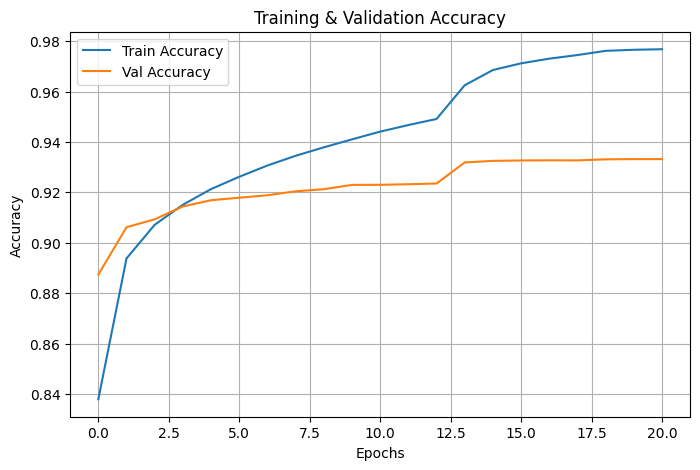

In [18]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

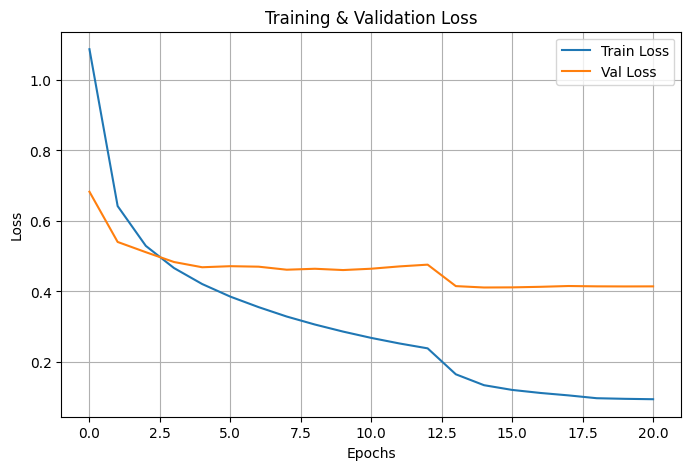

In [19]:
# Plot training & validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
target_vocab = target_vectorization.get_vocabulary()
target_index_lookup = dict(zip(range(len(target_vocab)), target_vocab))
max_decoded_sentence_length = 30

# Greedy decoding for translation
def decode_sequence(input_sentence):
    # Convert input sentence into tokens
    tokenized_input_sentence = source_vectorization([input_sentence])
    decoded_sentence = "[start]"

    for i in range(max_decoded_sentence_length):
        # Tokenize current decoded text
        tokenized_target_sentence = target_vectorization(
            [decoded_sentence])[:, :-1]

        # Predict next token
        predictions = transformer(
            [tokenized_input_sentence, tokenized_target_sentence])
        sampled_token_index = np.argmax(predictions[0, i, :])
        sampled_token = target_index_lookup[sampled_token_index]

        # Add predicted word to sentence
        decoded_sentence += " " + sampled_token
        if sampled_token == "[end]":
            break
    return decoded_sentence

# 50 random sentences translation
for i in range(50):
    random_index = np.random.randint(0, len(test_df))
    input_sentence = test_df["source"].iloc[random_index]
    print(input_sentence)
    print(decode_sequence(input_sentence))
    print()

Would you like to attend the Mardi Gras parade in New Orleans?
[start] möchtest du gerne zur mardi grasparade in new orleans [end]

I am not a Canadian
[start] ich bin kein kanadier [end]

He'll catch up with us in an hour
[start] er wird in einer stunde uns fangen [end]

What a loss!
[start] was für ein verlust [end]

Stop it, Tom
[start] hör auf tom [end]

No one asked for your help
[start] niemand hat dich um hilfe gebeten [end]

It's unbelievable
[start] es ist unglaublich [end]

I'd like to be a teacher
[start] ich möchte gerne lehrerin werden [end]

Tom has failed
[start] tom ist durchgefallen [end]

That's what Tom thinks
[start] das ist was tom denkt [end]

There's a big hole
[start] da ist ein großes loch [end]

It's the only thing we can do
[start] es ist das einzige was wir tun können [end]

What you did was really stupid
[start] was du wirklich war [UNK] [end]

I need to make a telephone call
[start] ich muss ein telefon telefonieren [end]

What kind of sick weirdo are you?

In [ ]:
# testing the model
print(decode_sequence("i am smart"))
print(decode_sequence("she is smart"))
print(decode_sequence("my brother plays the piano"))
print(decode_sequence("he is a waiter "))

[start] ich bin schlau [end]
[start] sie ist klug [end]
[start] mein bruder spielt klavier [end]
[start] er ist kellner [end]


In [ ]:
# Pronunciation help (IPA + slowed audio)
!pip install epitran==1.3.0 gTTS pydub --quiet
!apt-get update -qq
!apt-get install -y -qq ffmpeg  # pydub needs ffmpeg

import epitran # epitran converts written text into how it sounds when spoken
from gtts import gTTS
from pydub import AudioSegment
from IPython.display import Audio, display, HTML
import io
import os

# Initializing epitran for German (Latin script)
epi = epitran.Epitran('deu-Latn')

def german_to_ipa(text):
    text = text.replace("[start]", "").replace("[end]", "").strip()
    ipa = epi.transliterate(text)
    return 

def german_tts_and_slow(text, lang='de', slow_factor=0.6):
    tts = gTTS(text=text, lang=lang)
    tmpfile = "/tmp/german_tts.mp3"
    tts.save(tmpfile)
    aud = AudioSegment.from_file(tmpfile, format="mp3")

    # slowed: change frame_rate to slow playback
    slowed = aud._spawn(aud.raw_data, overrides={
        "frame_rate": int(aud.frame_rate * slow_factor)
    }).set_frame_rate(aud.frame_rate)

    # export to bytes for playback
    b1 = io.BytesIO()
    b2 = io.BytesIO()
    aud.export(b1, format="wav")
    slowed.export(b2, format="wav")
    b1.seek(0); b2.seek(0)
    return b1, b2

# UI wrapper: given an English input, decode using your transformer, show German + IPA + playback
def show_pronunciation_for(input_sentence):
    german = decode_sequence(input_sentence) 
    ipa = german_to_ipa(german)
    print("Input (EN):", input_sentence)
    print("Output (DE):", german)
    print("IPA (DE):", ipa)

    # Audio Generation
    normal_wav, slowed_wav = german_tts_and_slow(german.replace("[start]", "").replace("[end]",""))
    display(HTML("<b>Play normal speed:</b>"))
    display(Audio(normal_wav.read(), autoplay=False))
    normal_wav.seek(0)
    display(HTML("<b>Play slowed (for pronunciation practice):</b>"))
    display(Audio(slowed_wav.read(), autoplay=False))

# Example usage:
for s in ["i am smart", "she is smart", "my brother plays the piano"]:
    show_pronunciation_for(s)
    print("-" * 60)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.9/78.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.7 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'multi_head_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/loca

Input (EN): i am smart
Output (DE): [start] ich bin schlau [end]
IPA (DE): ix bin ʃlauh


------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'multi_head_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'transformer_encoder' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'multi_head_attention_1' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see 

Input (EN): she is smart
Output (DE): [start] sie ist klug [end]
IPA (DE): t͡siː ist kluk


------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'multi_head_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'transformer_encoder' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'multi_head_attention_1' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see 

Input (EN): my brother plays the piano
Output (DE): [start] mein bruder spielt klavier [end]
IPA (DE): main pruːdər spiːlt klaːfiə


------------------------------------------------------------


In [ ]:
# Interactive speaking exercises (record -> whisper -> compare)
!pip install git+https://github.com/openai/whisper.git --quiet
!pip install jiwer --quiet
from IPython.display import Javascript, display, Audio, HTML
import base64, os, io, subprocess, sys, json, tempfile
import numpy as np
import whisper
import soundfile as sf
from jiwer import wer
import editdistance

# load whisper model
try:
    whisper_model
except NameError:
    whisper_model = whisper.load_model("small")  

# JavaScript code used in browser to record microphone audio
RECORD_JS = """
const sleep = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise((resolve) => {
  const reader = new FileReader()
  reader.onload = e => resolve(e.target.result)
  reader.readAsDataURL(blob)
})
var record = async function(sec=5){
  stream = await navigator.mediaDevices.getUserMedia({ audio: true });
  recorder = new MediaRecorder(stream);
  chunks = [];
  recorder.ondataavailable = e => chunks.push(e.data);
  recorder.start();
  await sleep(sec*1000);
  recorder.stop();
  await new Promise(resolve => recorder.onstop = resolve);
  blob = new Blob(chunks);
  base64 = await b2text(blob);
  return base64;
}
"""

def record_audio(seconds=5, filename="/content/recording.wav"):
    display(Javascript(RECORD_JS + f"record({seconds}).then(b => google.colab.kernel.invokeFunction('notebook.receiveRecording', [b], {{}}));"))
    # register callback to save the recording
    from google.colab import output
    def _save_b64(b64):
        header, data = b64.split(',', 1)
        b = base64.b64decode(data)
        with open(filename, "wb") as f:
            f.write(b)
    output.register_callback('notebook.receiveRecording', _save_b64)
    print(f"Recording for {seconds} seconds... Please speak into your microphone.")
 
    # wait until file exists (simple busy wait)
    import time
    timeout = seconds + 5
    start = time.time()
    while not os.path.exists(filename) and (time.time() - start) < timeout:
        time.sleep(0.1)
    if not os.path.exists(filename):
        raise RuntimeError("Recording not saved. Browser blocked mic or runtime error.")
    print("Saved:", filename)
    return filename

# text to IPA
def to_ipa(s):
    return epi.transliterate(s.replace("[start]","").replace("[end]","").strip())

# PER (phone error rate)
def phone_error_rate(ref_ipa, hyp_ipa):
    r = "".join(ref_ipa.split())
    h = "".join(hyp_ipa.split())
    if len(r) == 0:
        return 1.0 if len(h)>0 else 0.0
    dist = editdistance.eval(r, h)
    return dist / max(1, len(r))

# show prompt, play model TTS, record user, transcribe with whisper, compare
def interactive_pronunciation_task(input_sentence, record_seconds=5):
    target_german = decode_sequence(input_sentence)
    print("Target (DE):", target_german)

    target_ipa = to_ipa(target_german)
    print("Target IPA:", target_ipa)

    normal_wav, slowed_wav = german_tts_and_slow(target_german.replace("[start]","").replace("[end]",""))
    print("Playing model audio (normal speed). Listen and repeat:")
    display(Audio(normal_wav.read(), autoplay=False))
    normal_wav.seek(0)

    # recording user's attempt
    rec_file = record_audio(seconds=record_seconds, filename="/content/recording.wav")
    display(Audio(rec_file, autoplay=False))

    # transcribe user's audio with Whisper
    print("Transcribing user audio with Whisper...")
    res = whisper_model.transcribe(rec_file, language='de', task='transcribe')
    user_transcript = res.get("text", "").strip()
    print("Whisper transcript (user):", user_transcript)

    user_ipa = to_ipa(user_transcript)
    print("User IPA:", user_ipa)

    per = phone_error_rate(target_ipa, user_ipa)
    score = max(0.0, 1.0 - per) * 100.0
    print(f"Pronunciation score: {score:.1f}%  (phone error rate = {per:.3f})")

    # Computing WER (Word Eror Rate) for diagnostic:
    wer_val = wer(target_german.replace("[start]","").replace("[end]","").strip(), user_transcript)
    print(f"Word error rate (approx): {wer_val:.3f}")
    return {
        "target": target_german,
        "target_ipa": target_ipa,
        "user_transcript": user_transcript,
        "user_ipa": user_ipa,
        "score": score,
        "wer": wer_val,
        "audio_file": rec_file
    }

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 58.5 MB/s eta 0:00:00


100%|███████████████████████████████████████| 461M/461M [00:09<00:00, 49.5MiB/s]


In [52]:
# Example usage:
result = interactive_pronunciation_task("i am smart", record_seconds=5)
print(result)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'multi_head_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'transformer_encoder' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'multi_head_attention_1' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see 

Target (DE): [start] ich bin schlau [end]
Target IPA: ix bin ʃlauh
Playing model audio (normal speed). Listen and repeat:


<IPython.core.display.Javascript object>

Recording for 5 seconds... Please speak into your microphone.
Saved: /content/recording.wav


Transcribing user audio with Whisper...
Whisper transcript (user): in
User IPA: in
Pronunciation score: 20.0%  (phone error rate = 0.800)
Word error rate (approx): 1.000
{'target': '[start] ich bin schlau [end]', 'target_ipa': 'ix bin ʃlauh', 'user_transcript': 'in', 'user_ipa': 'in', 'score': 19.999999999999996, 'wer': 1.0, 'audio_file': '/content/recording.wav'}


In [ ]:
# Saving the model
transformer.save("GerTran.keras")

In [ ]:
# Save model, weights, vocabs, config, and metadata
import json, pickle, os

# 1) Saving full model
transformer.save("GerTran.keras") 

# 2) Saving weights-only checkpoint as well
checkpoint_filepath = 'checkpoint.weights.h5'
transformer.save_weights(checkpoint_filepath) 

# 3) Saving TextVectorization vocabularies
import json
json.dump(source_vectorization.get_vocabulary(), open("source_vocab_re.json","w", encoding="utf-8"))
json.dump(target_vectorization.get_vocabulary(), open("target_vocab_re.json","w", encoding="utf-8"))

# 4) Saving target index lookup (index -> token mapping)
target_vocab = target_vectorization.get_vocabulary()
target_index_lookup = dict(zip(range(len(target_vocab)), target_vocab))
json.dump(target_index_lookup, open("target_index_lookup.json","w", encoding="utf-8"))

# 5) Saving model hyperparameters / config
model_config = {
    "max_tokens": max_tokens,
    "sequence_length": sequence_length,
    "embed_dim": embed_dim,
    "dense_dim": dense_dim,
    "num_heads": num_heads,
    "batch_size": batch_size,
    "vocab_size_source": len(source_vectorization.get_vocabulary()),
    "vocab_size_target": len(target_vectorization.get_vocabulary())
}
json.dump(model_config, open("model_config.json","w", encoding="utf-8"))

# 6) Saving training history
try:
    with open("training_history.pkl", "wb") as f:
        pickle.dump(history.history, f)
except Exception as e:
    print("No history object found or failed to save history:", e)

# 7) Saving a copy of the preprocessed dataset
df.to_csv("english_to_german_saved_for_repro.csv", index=False)